# Zero Shot Training
The purpose of this training is to get the embeddings for use in slider font customization.

In [1]:
# Importing
from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

/home/ljvaughn0841/Projects/TheFontinator/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [2]:
import torch
from transformers import AutoModel
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model.to(device)
# Ensure input tensors are also on the 'device'

Using device: cuda


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [3]:
# Ensure you are running on GPU if possible.
print(model.device)

cuda:0


In [4]:
from PIL import Image
def embed_image(image_path):
    image = Image.open(image_path)

    inputs = processor(
        images=image,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        image_features = model.get_image_features(**inputs)

    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    return image_features.cpu().numpy()[0]

In [5]:
embed_image("font-photos/silkscreen.png")

array([ 1.91216730e-02,  4.50886302e-02,  3.42306308e-02, -9.89666395e-03,
        5.08010648e-02, -4.10557799e-02,  3.24611142e-02,  2.11373083e-02,
        8.62506311e-03,  7.62014985e-02, -4.64297226e-03, -2.90476568e-02,
        2.47094762e-02, -1.73885841e-02,  6.90666363e-02, -1.64100179e-03,
        2.66347434e-02, -1.85501333e-02,  1.36786292e-03, -1.96293276e-02,
        4.65113902e-03, -3.74057591e-02, -1.10997935e-03,  3.63894776e-02,
       -6.72828928e-02,  2.29769573e-02, -3.46963368e-02,  3.88694480e-02,
       -1.20614213e-03, -1.07901813e-02,  3.94717902e-02,  2.14911043e-03,
        2.55400203e-02, -4.44430253e-03,  1.37761123e-02, -4.24896441e-02,
        5.69172688e-02,  1.80530772e-02, -9.81725520e-04, -8.97927061e-02,
       -1.86972152e-02, -3.01121864e-02, -4.31950018e-02, -5.37304059e-02,
        1.91878639e-02, -1.69928912e-02,  4.24360707e-02, -1.66814663e-02,
       -1.79900555e-03,  5.93783073e-02,  2.39706542e-02,  1.87482487e-03,
        2.23789308e-02,  

In [6]:
import os
import numpy as np
from tqdm import tqdm

image_dir = "font-photos"

embeddings = []
font_ids = []

for fname in tqdm(os.listdir(image_dir)):
    if fname.endswith(".png"):
        path = os.path.join(image_dir, fname)
        emb = embed_image(path)

        embeddings.append(emb)
        font_ids.append(fname.replace(".png", ""))

embeddings = np.vstack(embeddings)


100%|██████████| 1180/1180 [00:10<00:00, 108.10it/s]


In [7]:
font_ids

['imperialscript',
 'wixmadefortext',
 'prata',
 'gabriela',
 'eduvicwantbeginner',
 'jockeyone',
 'ptserifcaption',
 'eduauvicwantdots',
 'antic',
 'miama',
 'whisper',
 'sourcecodepro',
 'squarepeg',
 'combo',
 'sofia',
 'freeman',
 'crimsontext',
 'almendradisplay',
 'joan',
 'newamsterdam',
 'saira',
 'concertone',
 'newrocker',
 'novasquare',
 'cormorantunicase',
 'plusjakartasans',
 'merienda',
 'candal',
 'libertinusmath',
 'averiasanslibre',
 'prozalibre',
 'spirax',
 'spinnaker',
 'wixmadefordisplay',
 'signikasc',
 'supermercadoone',
 'sedansc',
 'rem',
 'winkysans',
 'mozillatext',
 'kellyslab',
 'portlligatsans',
 'jacquard12charted',
 'rethinksans',
 'twinklestar',
 'ledger',
 'kalniaglaze',
 'bungeehairline',
 'barriecito',
 'bitcountpropdoubleink',
 'miltoniantattoo',
 'cookie',
 'lilex',
 'scopeone',
 'chivo',
 'basic',
 'rubik',
 'librebaskerville',
 'poly',
 'cedarvillecursive',
 'uncialantiqua',
 'federant',
 'greyqo',
 'arbutus',
 'lexendpeta',
 'redditsanscondensed

In [8]:
embeddings

array([[-0.04414342, -0.02710756, -0.0379068 , ...,  0.02207095,
        -0.01793541,  0.01918712],
       [ 0.01636475,  0.02987909,  0.01012277, ...,  0.0007662 ,
        -0.03957108,  0.01309821],
       [-0.0039209 ,  0.01375641,  0.00309662, ...,  0.00350845,
        -0.05404161,  0.01702644],
       ...,
       [-0.01281461,  0.04146094, -0.03350754, ...,  0.0572945 ,
        -0.0153939 ,  0.01799189],
       [-0.00468114,  0.03108103,  0.02538202, ..., -0.00712607,
        -0.05558038,  0.00967562],
       [-0.01621431,  0.02934127,  0.01403422, ...,  0.00792215,
        -0.02980117,  0.00718908]], shape=(1180, 512), dtype=float32)

In [9]:
font_ids.index("silkscreen")

1081

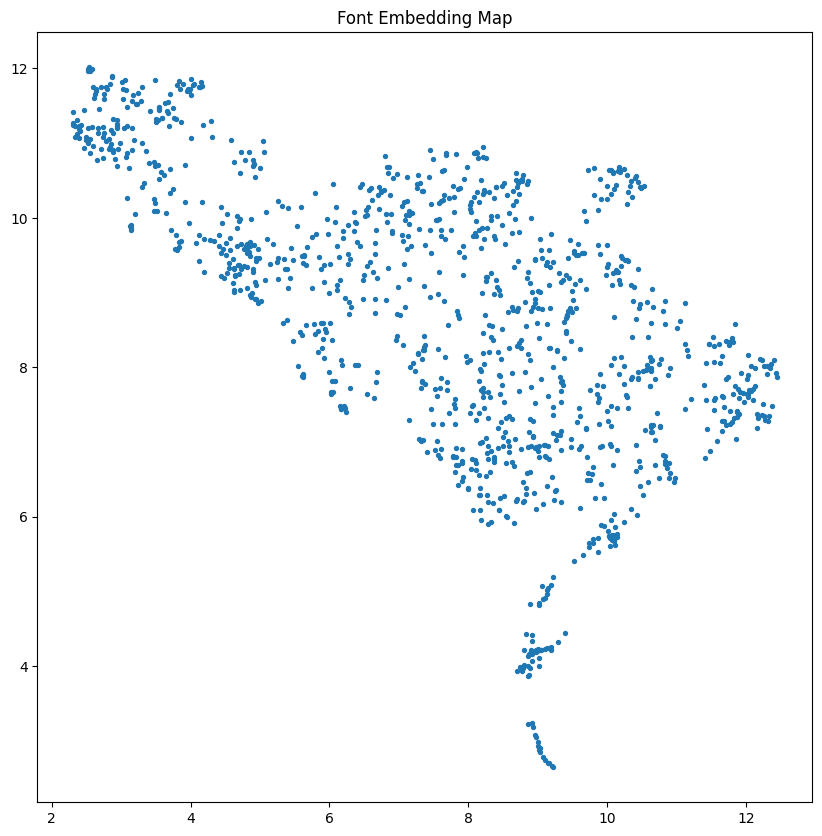

In [10]:
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine"
)

coords = reducer.fit_transform(embeddings)

plt.figure(figsize=(10, 10))
plt.scatter(coords[:, 0], coords[:, 1], s=8)
plt.title("Font Embedding Map")
plt.show()


In [11]:
import numpy as np
from math import ceil, sqrt

n = coords.shape[0]
grid_size = ceil(sqrt(n))

xs = np.linspace(coords[:,0].min(), coords[:,0].max(), grid_size)
ys = np.linspace(coords[:,1].min(), coords[:,1].max(), grid_size)

grid = np.array([
    (x, y)
    for y in ys
    for x in xs
])[:n]


In [12]:
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

cost = cdist(coords, grid)
row_ind, col_ind = linear_sum_assignment(cost)

grid_coords = grid[col_ind]


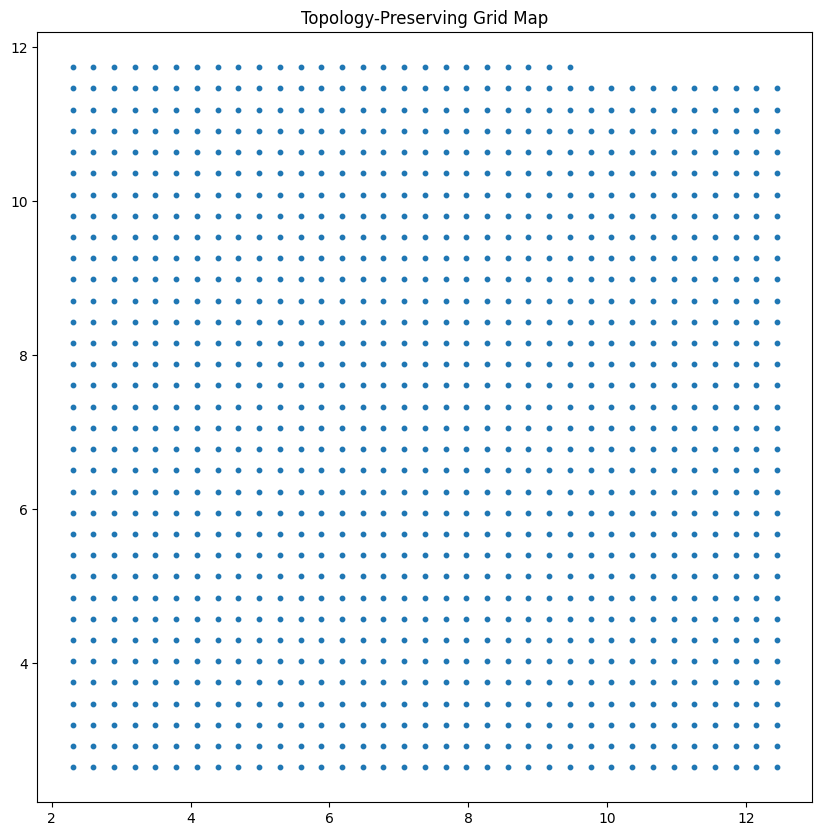

In [13]:
plt.figure(figsize=(10, 10))
plt.scatter(grid_coords[:, 0], grid_coords[:, 1], s=10)
plt.title("Topology-Preserving Grid Map")
plt.show()


In [14]:
# Grid Coords still match up in order of font_ids
grid_coords

array([[ 2.895771 ,  8.435083 ],
       [ 7.9715347,  4.027959 ],
       [ 8.568684 , 10.363201 ],
       ...,
       [ 4.0900683, 11.189537 ],
       [11.554426 ,  5.956076 ],
       [ 2.895771 ,  4.854295 ]], shape=(1180, 2), dtype=float32)

In [15]:
# Save the Grid Coords and the id's for use in backend
proj_dir = os.getcwd().rsplit('/', 1)[0]
np.save(proj_dir + '/backend/data/GridCoords', grid_coords)

# Named font data because I'll probably expand this table to have metadata
# Converts to numpy for now
font_ids_np = np.array(font_ids)
np.save(proj_dir + '/backend/data/FontData', font_ids_np)

In [16]:
font_ids_np

array(['imperialscript', 'wixmadefortext', 'prata', ..., 'alexbrush',
       'gluten', 'jimnightshade'], shape=(1180,), dtype='<U28')

In [32]:
sliders = {
    "seriousness": [
        "serious professional corporate font",
        "playful fun cartoon font"
    ],
    "modernness": [
        "modern clean minimalist font",
        "classic traditional old font"
    ],
    "elegance": [
        "elegant luxury fashion font",
        "loud bold display font"
    ],
    "humanity": [
        "human handwritten script font",
        "technical monospace computer font"
    ],
    "energy": [
    "energetic dynamic expressive font",
    "calm stable restrained font"
    ],
    "density": [
      "compact dense information-heavy font",
      "open airy spacious font"
    ],
    "readability": [
    "highly readable clear body text font",
    "expressive decorative hard to read font"
    ]
}


In [51]:
classes = [ "serious professional corporate font",
            "playful fun cartoon font",
        "modern clean minimalist font",
        "classic traditional old font",
        "elegant luxury fashion font",
        "loud bold display font",
        "human handwritten script font",
        "technical monospace computer font",
        "energetic dynamic expressive font",
        "calm stable restrained font",
        "compact dense information-heavy font",
        "open airy spacious font",
        "highly readable clear body text font",
        "expressive decorative hard to read font"]

In [52]:
sliders["seriousness"]

['serious professional corporate font', 'playful fun cartoon font']

In [53]:
img_emb = embed_image("font-photos/alexbrush.png")

In [ ]:
image_dir = "font-photos"

for slider in sliders:
  img_probs = None
  # embeddings = []
  slider_font_ids = []

  for fname in tqdm(os.listdir(image_dir)):
      if fname.endswith(".png"):
          image_path = os.path.join(image_dir, fname)
          image = Image.open(image_path)
          inputs = processor(text=classes, images=image, return_tensors="pt", padding=True, do_convert_rgb=False)
          outputs = model(**inputs)

          logits_per_image = outputs.logits_per_image  # this is the image-text similarity score
          probs = logits_per_image.softmax(dim=1)  # we can take the softmax to get the label probabilities

          img_probs.append(emb)
          slider_font_ids.append(fname.replace(".png", ""))

probabilities = np.vstack(img_probs)

  0%|          | 0/1180 [00:00<?, ?it/s]


NameError: name 'image_path' is not defined

In [ ]:
classes = ['giraffe', 'zebra', 'elephant']

inputs = processor(text=classes, images=images, return_tensors="pt", padding=True, do_convert_rgb=False)

outputs = model(**inputs)
logits_per_image = outputs.logits_per_image  # this is the image-text similarity score
probs = logits_per_image.softmax(dim=1)  # we can take the softmax to get the label probabilities

In [ ]:
image_dir = "font-photos"

embeddings = []
font_ids = []

for fname in tqdm(os.listdir(image_dir)):
    if fname.endswith(".png"):
        path = os.path.join(image_dir, fname)

        emb = embed_image(path)

        embeddings.append(emb)
        font_ids.append(fname.replace(".png", ""))

embeddings = np.vstack(embeddings)
